In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"




import os
import math
import time
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras as K
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)



gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("memory growth enabled")
    except RuntimeError as e:
        print(e)






loadPath = '/home/sz4544/EEG-motor-imagery-main/project/'

f_train = h5py.File(os.path.join(loadPath, "train12720_raw_EEG.h5"), "r")
tr_data = f_train['data'][:]
ytr = f_train['tasks'][:]
tr_subjects = f_train['subjects'][:]

print("tr_data shape:", tr_data.shape)
print("ytr shape:", ytr.shape)
print("subjects shape:", tr_subjects.shape)
print("unique labels:", np.unique(ytr))


ytr = ytr.astype(np.int32)

# 如果原标签是 1,2,3,4，则改成 0,1,2,3
if np.array_equal(np.unique(ytr), np.array([1, 2, 3, 4])):
    ytr = ytr - 1

print("unique labels after remap:", np.unique(ytr))
num_classes = 4



from sklearn.preprocessing import StandardScaler

# reshape to (12720*640, 64)
xtr_flat = np.squeeze(tr_data).reshape((-1, 64))
print("xtr_flat shape:", xtr_flat.shape)

scaler = StandardScaler()
xtr_flat_scaled = scaler.fit_transform(xtr_flat)

x_train = xtr_flat_scaled.reshape((-1, 640, 64, 1)).astype(np.float32)
y_train = ytr.astype(np.int32)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_train dtype:", x_train.dtype)

import pickle

scaler_path = os.path.join(loadPath, "models", "cwgangp_full_dataset_scaler.pkl")
os.makedirs(os.path.join(loadPath, "models"), exist_ok=True)

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

print("saved scaler to:", scaler_path)


batch_size = 16

class EEGTrainSequence(K.utils.Sequence):
    def __init__(self, x, y, batch_size=16, shuffle=True):
        self.x = x
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.x))
        self.on_epoch_end()

    def __len__(self):
        return len(self.indices) // self.batch_size

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_x = self.x[batch_idx]
        batch_y = self.y[batch_idx]
        return batch_x, batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

train_seq = EEGTrainSequence(x_train, y_train, batch_size=batch_size, shuffle=True)

print("train_seq ready")
print("num batches per epoch:", len(train_seq))


latent_dim = 128
critic_steps = 5
gp_weight = 10.0
epochs = 100

model_save_path = os.path.join(loadPath, "models", "cwgangp_generator_full_dataset.keras")
history_save_path = os.path.join(loadPath, "models", "cwgangp_training_history_full_dataset.npz")

print("latent_dim:", latent_dim)
print("critic_steps:", critic_steps)
print("gp_weight:", gp_weight)
print("epochs:", epochs)
print("generator save path:", model_save_path)

I0000 00:00:1773985587.260368    6548 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
memory growth enabled
tr_data shape: (12720, 640, 64)
ytr shape: (12720,)
subjects shape: (12720,)
unique labels: [1. 2. 3. 4.]
unique labels after remap: [0 1 2 3]
xtr_flat shape: (8140800, 64)
x_train shape: (12720, 640, 64, 1)
y_train shape: (12720,)
x_train dtype: float32
saved scaler to: /home/sz4544/EEG-motor-imagery-main/project/models/cwgangp_full_dataset_scaler.pkl
train_seq ready
num batches per epoch: 795
latent_dim: 128
critic_steps: 5
gp_weight: 10.0
epochs: 100
generator save path: /home/sz4544/EEG-motor-imagery-main/project/models/cwgangp_generator_full_dataset.keras


In [3]:
def build_generator(latent_dim=128, num_classes=4):
    noise_input = layers.Input(shape=(latent_dim,), name="noise_input")
    label_input = layers.Input(shape=(1,), dtype="int32", name="label_input")

    label_embed = layers.Embedding(num_classes, 32)(label_input)
    label_embed = layers.Flatten()(label_embed)

    x = layers.Concatenate()([noise_input, label_embed])

    x = layers.Dense(80 * 8 * 64, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Reshape((80, 8, 64))(x)

    x = layers.Conv2DTranspose(64, kernel_size=(4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)   # (160, 16, 64)

    x = layers.Conv2DTranspose(32, kernel_size=(4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)   # (320, 32, 32)

    x = layers.Conv2DTranspose(16, kernel_size=(4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)   # (640, 64, 16)

    x = layers.Conv2D(8, kernel_size=(3, 3), padding="same")(x)
    x = layers.ReLU()(x)

    out = layers.Conv2D(1, kernel_size=(3, 3), padding="same", activation="tanh", name="generated_trial")(x)

    return K.Model([noise_input, label_input], out, name="generator")








def build_critic(num_classes=4):
    trial_input = layers.Input(shape=(640, 64, 1), name="trial_input")
    label_input = layers.Input(shape=(1,), dtype="int32", name="label_input")

    label_embed = layers.Embedding(num_classes, 640 * 64)(label_input)
    label_embed = layers.Flatten()(label_embed)
    label_embed = layers.Reshape((640, 64, 1))(label_embed)

    x = layers.Concatenate(axis=-1)([trial_input, label_embed])

    x = layers.Conv2D(32, kernel_size=(15, 9), strides=(2, 1), padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(64, kernel_size=(15, 9), strides=(2, 1), padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, kernel_size=(9, 5), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128)(x)
    x = layers.LeakyReLU(0.2)(x)

    out = layers.Dense(1, name="critic_score")(x)

    return K.Model([trial_input, label_input], out, name="critic")

def show_gpu_memory(tag=""):
    try:
        info = tf.config.experimental.get_memory_info('GPU:0')
        current_mb = info['current'] / 1024 / 1024
        peak_mb = info['peak'] / 1024 / 1024
        print(f"[{tag}] GPU current={current_mb:.2f} MB, peak={peak_mb:.2f} MB")
    except Exception as e:
        print(f"[{tag}] GPU memory info unavailable: {e}")

generator = build_generator(latent_dim=latent_dim, num_classes=num_classes)
show_gpu_memory("after generator build")

critic = build_critic(num_classes=num_classes)
show_gpu_memory("after critic build")

print(generator.summary())
print(critic.summary())
show_gpu_memory("after summaries")



generator_optimizer = K.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.9)
critic_optimizer = K.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.9)





def gradient_penalty(critic, real_samples, fake_samples, labels):
    alpha = tf.random.uniform([real_samples.shape[0], 1, 1, 1], 0.0, 1.0)
    interpolated = alpha * real_samples + (1 - alpha) * fake_samples

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        pred = critic([interpolated, labels], training=True)

    grads = tape.gradient(pred, interpolated)
    grads = tf.reshape(grads, [grads.shape[0], -1])
    norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=1) + 1e-12)
    gp = tf.reduce_mean((norm - 1.0) ** 2)
    return gp



@tf.function
def train_critic_step(real_trials, real_labels):
    batch_size_local = tf.shape(real_trials)[0]
    noise = tf.random.normal([batch_size_local, latent_dim])

    with tf.GradientTape() as tape:
        fake_trials = generator([noise, real_labels], training=True)

        critic_real = critic([real_trials, real_labels], training=True)
        critic_fake = critic([fake_trials, real_labels], training=True)

        wasserstein_loss = tf.reduce_mean(critic_fake) - tf.reduce_mean(critic_real)
        gp = gradient_penalty(critic, real_trials, fake_trials, real_labels)
        critic_loss = wasserstein_loss + gp_weight * gp

    grads = tape.gradient(critic_loss, critic.trainable_variables)
    critic_optimizer.apply_gradients(zip(grads, critic.trainable_variables))

    return critic_loss, wasserstein_loss, gp


@tf.function
def train_generator_step(real_labels):
    batch_size_local = tf.shape(real_labels)[0]
    noise = tf.random.normal([batch_size_local, latent_dim])

    with tf.GradientTape() as tape:
        fake_trials = generator([noise, real_labels], training=True)
        critic_fake = critic([fake_trials, real_labels], training=True)
        generator_loss = -tf.reduce_mean(critic_fake)

    grads = tape.gradient(generator_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(grads, generator.trainable_variables))

    return generator_loss


show_gpu_memory("before training loop")
critic_losses = []
generator_losses = []
gp_losses = []

start_time = time.time()

for epoch in range(epochs):
    epoch_critic_losses = []
    epoch_generator_losses = []
    epoch_gp_losses = []

    for batch_idx in range(len(train_seq)):
        real_trials, real_labels = train_seq[batch_idx]

        real_trials = tf.convert_to_tensor(real_trials, dtype=tf.float32)
        real_labels = tf.convert_to_tensor(real_labels, dtype=tf.int32)
        real_labels = tf.expand_dims(real_labels, axis=1)

        for _ in range(critic_steps):
            c_loss, w_loss, gp_loss = train_critic_step(real_trials, real_labels)
            epoch_critic_losses.append(float(c_loss))
            epoch_gp_losses.append(float(gp_loss))

        g_loss = train_generator_step(real_labels)
        epoch_generator_losses.append(float(g_loss))

        if batch_idx % 100 == 0:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"batch {batch_idx}/{len(train_seq)} | "
                f"critic_loss={float(c_loss):.4f} | "
                f"generator_loss={float(g_loss):.4f} | "
                f"gp={float(gp_loss):.4f}"
            )
            show_gpu_memory(f"epoch {epoch+1} batch {batch_idx}")

    critic_losses.append(np.mean(epoch_critic_losses))
    generator_losses.append(np.mean(epoch_generator_losses))
    gp_losses.append(np.mean(epoch_gp_losses))

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"critic_loss={critic_losses[-1]:.4f} | "
        f"generator_loss={generator_losses[-1]:.4f} | "
        f"gp={gp_losses[-1]:.4f}"
    )

    train_seq.on_epoch_end()

print("training finished in {:.2f} minutes".format((time.time() - start_time) / 60.0))






[after generator build] GPU current=66.36 MB, peak=129.17 MB
[after critic build] GPU current=229.48 MB, peak=741.48 MB


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 32)     │        128 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 160)       │          0 │ noise_input[0][0… │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 40960)     │  6,553,600 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40960)     │    163,840 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 40960)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 80, 8, 64) │          0 │ re_lu_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 160, 16,   │     65,536 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 16,   │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 160, 16,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 320, 32,   │     32,768 │ re_lu_6[0][0]     │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 32,   │        128 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 320, 32,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 640, 64,   │      8,192 │ re_lu_7[0][0]     │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 640, 64,   │         64 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 640, 64,   │          0 │ batch_normalizat… │
│                     │ 16)               │            │                 

 Total params: 6,825,745 (26.04 MB)

 Trainable params: 6,743,601 (25.72 MB)

...

 Trainable params: 42,761,121 (163.12 MB)

 Non-trainable params: 0 (0.00 B)

None
[after summaries] GPU current=229.48 MB, peak=741.48 MB
[before training loop] GPU current=229.48 MB, peak=741.48 MB


I0000 00:00:1773985647.022217    6779 cuda_dnn.cc:461] Loaded cuDNN version 90800


Epoch 1/100 | batch 0/795 | critic_loss=-75.4186 | generator_loss=85.3692 | gp=0.0503
[epoch 1 batch 0] GPU current=782.27 MB, peak=2011.74 MB
Epoch 1/100 | batch 100/795 | critic_loss=-407.6689 | generator_loss=-508.1460 | gp=27.4144
[epoch 1 batch 100] GPU current=781.96 MB, peak=2011.74 MB
Epoch 1/100 | batch 200/795 | critic_loss=-417.6933 | generator_loss=-824.3007 | gp=30.3042
[epoch 1 batch 200] GPU current=781.96 MB, peak=2011.74 MB
Epoch 1/100 | batch 300/795 | critic_loss=-286.9006 | generator_loss=-680.0126 | gp=16.9048
[epoch 1 batch 300] GPU current=781.96 MB, peak=2011.74 MB
Epoch 1/100 | batch 400/795 | critic_loss=-519.3105 | generator_loss=-3740.9653 | gp=44.0801
[epoch 1 batch 400] GPU current=781.96 MB, peak=2011.74 MB
Epoch 1/100 | batch 500/795 | critic_loss=-532.4736 | generator_loss=-4324.4707 | gp=21.1724
[epoch 1 batch 500] GPU current=781.96 MB, peak=2020.75 MB
Epoch 1/100 | batch 600/795 | critic_loss=-749.1923 | generator_loss=-4509.0869 | gp=56.0749
[epoch 

saved generator to: /home/sz4544/EEG-motor-imagery-main/project/models/cwgangp_generator_full_dataset.keras
saved history to: /home/sz4544/EEG-motor-imagery-main/project/models/cwgangp_training_history_full_dataset.npz


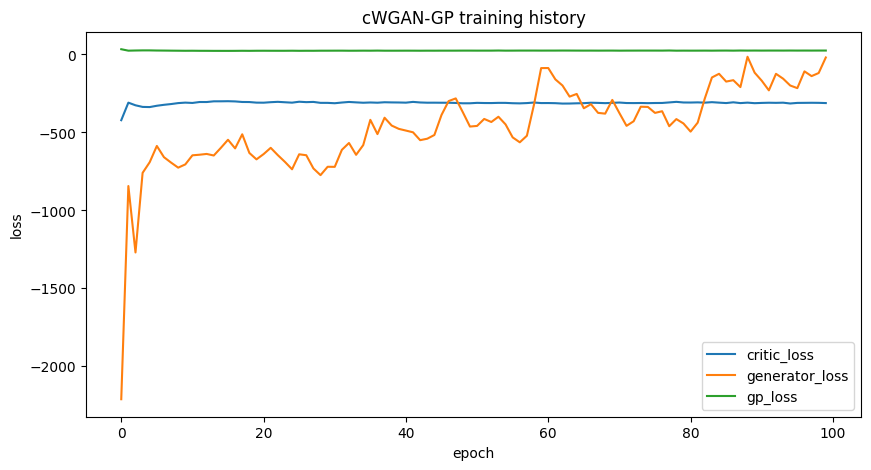

sample_trials shape: (4, 640, 64, 1)
min: -1.0 max: 1.0


In [5]:
generator.save(model_save_path)

np.savez(
    history_save_path,
    critic_losses=np.array(critic_losses),
    generator_losses=np.array(generator_losses),
    gp_losses=np.array(gp_losses)
)

print("saved generator to:", model_save_path)
print("saved history to:", history_save_path)

plt.figure(figsize=(10, 5))
plt.plot(critic_losses, label="critic_loss")
plt.plot(generator_losses, label="generator_loss")
plt.plot(gp_losses, label="gp_loss")
plt.legend()
plt.title("cWGAN-GP training history")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

sample_labels = tf.constant([[0], [1], [2], [3]], dtype=tf.int32)
sample_noise = tf.random.normal([4, latent_dim], dtype=tf.float32)

sample_trials = generator([sample_noise, sample_labels], training=False).numpy()

print("sample_trials shape:", sample_trials.shape)
print("min:", sample_trials.min(), "max:", sample_trials.max())